# Differential Logic Part 2: Weather Deduction 

blog post: https://fualsan.github.io/posts/differential-logic-part-2/

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.25'

%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import pandas as pd
from functools import partial

from relaxation import logistic_sigmoid_relaxation_gt, logistic_sigmoid_relaxation_lt
from logic_utils import binarize, calculate_metrics
from triangular_norms import diff_and, diff_not, diff_implies, diff_or, diff_equivalence

In [2]:
diff_imp_prob_sum = partial(diff_implies, name_tconorm='probabilistic_sum')
diff_eq_prod_sum = partial(diff_equivalence, name_tnorm='product', name_tconorm='probabilistic_sum')

## Hyperparameters

In [3]:
SEED = 1234 # FOR REPRODUCIBILITY
SPLIT_RATIO = 0.2 # 80% TRAINING, 20% TEST SPLIT

STEEPNESS = 1.0
NUM_EPOCHS = 20
LEARNING_RATE = 0.01

relaxation_fn = logistic_sigmoid_relaxation_gt

## Weather Dataset

sampled dataset source: https://www.kaggle.com/datasets/nikhil7280/weather-type-classification

In [4]:
df_weather = pd.read_csv('./weather_classification_data.csv')
df_weather.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


## Class Distribution

In [5]:
df_weather['Weather Type'].value_counts()

Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

## Mean Differences

In [6]:
df_numerical_only = df_weather.select_dtypes(include='number')
df_numerical_only['Weather Type'] = df_weather['Weather Type']
df_numerical_only.groupby('Weather Type').agg(['mean'])

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
,mean,mean,mean,mean,mean,mean,mean
Weather Type,,,,,,,
Cloudy,22.823636,66.528788,8.601818,40.286364,1010.170724,3.583939,7.071212
Rainy,22.788182,78.397879,13.677576,74.752424,1004.149848,2.684242,3.628485
Snowy,-1.530606,78.510303,10.976212,74.586061,991.051842,1.950303,3.591515
Sunny,32.429091,51.406364,6.073182,24.952727,1017.939170,7.804545,7.560455


## Train/Test Split

In [7]:
df_features_train, df_features_test, df_labels_train, df_labels_test = train_test_split(
    df_weather.drop(columns=['Weather Type']),
    df_weather['Weather Type'],
    test_size=SPLIT_RATIO,
    random_state=SEED,
    stratify=df_weather['Weather Type'], # ENSURE LABELS DISTRIBUTED EQUALLY
)

## Select & Scale Features to Learn

In [8]:
#FEATURE_NAME = 'Temperature'
FEATURE_NAME = 'UV Index'
#FEATURE_NAME = 'Wind Speed'

TARGET_NAME = 'Sunny'

In [9]:
# [-4.0, 4.0] RANGE IS FOR SIGMOID NUMERICAL STABILITY
scaler = MinMaxScaler(feature_range=(-4.0, 4.0))

In [10]:
df_features_train[[FEATURE_NAME]] = scaler.fit_transform(df_features_train[[FEATURE_NAME]])
df_features_test[[FEATURE_NAME]] = scaler.transform(df_features_test[[FEATURE_NAME]])

In [11]:
x_features_train = jnp.array(df_features_train[FEATURE_NAME])
x_features_test = jnp.array(df_features_test[FEATURE_NAME])
x_target_train = jnp.array((df_labels_train == TARGET_NAME).astype(jnp.float32))
x_target_test = jnp.array((df_labels_test == TARGET_NAME).astype(jnp.float32))

## Differential Optimization of Relaxation

Initial value of condition: -1.7295


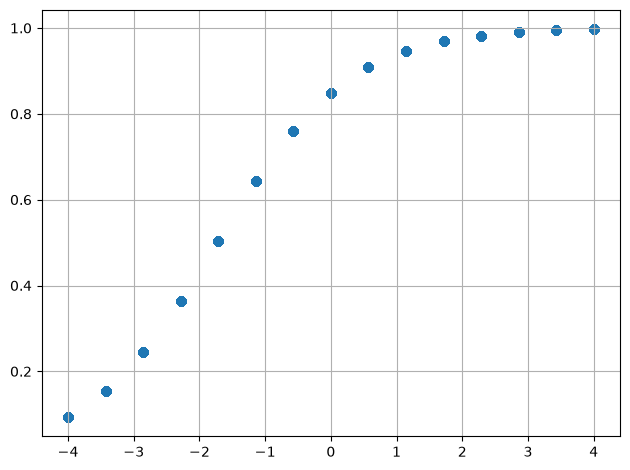

In [12]:
# INITIALIZE CONDIITON AS THE MEAN OF THE COLUMN
x_condition = jnp.mean(x_features_train)
print(f'Initial value of condition: {x_condition.item():2.4f}')

x_pred_train = relaxation_fn(x_features_train, x_condition, STEEPNESS)

plt.scatter(x_features_train, x_pred_train)
plt.grid('on')
plt.tight_layout()

## Final Average Truth

In [13]:
def final_avg_truth(x, c, s, target):
    pred = relaxation_fn(x, c, s)
    truth_i = diff_eq_prod_sum(pred, target)
    return jnp.mean(truth_i)

final_avg_truth(x_features_train, x_condition, STEEPNESS, x_target_train)

Array(0.71444535, dtype=float32)

## Main Optimization Loop

In [14]:
grad_fn = jax.value_and_grad(final_avg_truth, argnums=(1,))

inv_transform = lambda x: scaler.inverse_transform(x.reshape(-1, 1)).ravel()

for epoch in range(1, NUM_EPOCHS+1):
    loss, grads = grad_fn(x_features_train, x_condition, STEEPNESS, x_target_train)
    x_condition = x_condition + LEARNING_RATE*grads[0]

    ###### FOR METRICS ONLY ######
    x_pred_train = relaxation_fn(x_features_train, x_condition, STEEPNESS)
    pred_dict_train = calculate_metrics(x_pred_train, x_target_train)
    ##############################
    
    print(f'Epoch: {epoch:2d}, Truth: {loss:2.2f}, Accuracy: {pred_dict_train["Accuracy"].item():2.2f}%, F-1: {pred_dict_train["F-1"].item():2.2f}')

Epoch:  1, Truth: 0.71, Accuracy: 81.61%, F-1: 0.72
Epoch:  2, Truth: 0.71, Accuracy: 81.61%, F-1: 0.72
Epoch:  3, Truth: 0.71, Accuracy: 81.61%, F-1: 0.72
Epoch:  4, Truth: 0.71, Accuracy: 81.61%, F-1: 0.72
Epoch:  5, Truth: 0.71, Accuracy: 81.61%, F-1: 0.72
Epoch:  6, Truth: 0.71, Accuracy: 81.61%, F-1: 0.72
Epoch:  7, Truth: 0.71, Accuracy: 81.61%, F-1: 0.72
Epoch:  8, Truth: 0.71, Accuracy: 81.61%, F-1: 0.72
Epoch:  9, Truth: 0.71, Accuracy: 81.61%, F-1: 0.72
Epoch: 10, Truth: 0.72, Accuracy: 81.61%, F-1: 0.72
Epoch: 11, Truth: 0.72, Accuracy: 81.61%, F-1: 0.72
Epoch: 12, Truth: 0.72, Accuracy: 81.61%, F-1: 0.72
Epoch: 13, Truth: 0.72, Accuracy: 81.61%, F-1: 0.72
Epoch: 14, Truth: 0.72, Accuracy: 81.61%, F-1: 0.72
Epoch: 15, Truth: 0.72, Accuracy: 81.61%, F-1: 0.72
Epoch: 16, Truth: 0.72, Accuracy: 81.61%, F-1: 0.72
Epoch: 17, Truth: 0.72, Accuracy: 81.61%, F-1: 0.72
Epoch: 18, Truth: 0.72, Accuracy: 81.61%, F-1: 0.72
Epoch: 19, Truth: 0.72, Accuracy: 86.96%, F-1: 0.78
Epoch: 20, T

## Inverse Feature Scaling to Original Values

In [15]:
x_features_train = inv_transform(x_features_train)
x_features_test = inv_transform(x_features_test)
x_condition = inv_transform(x_condition)

## Learned Condition

Learned condition: 4.0019


Text(42.722222222222214, 0.5, 'Truth Value')

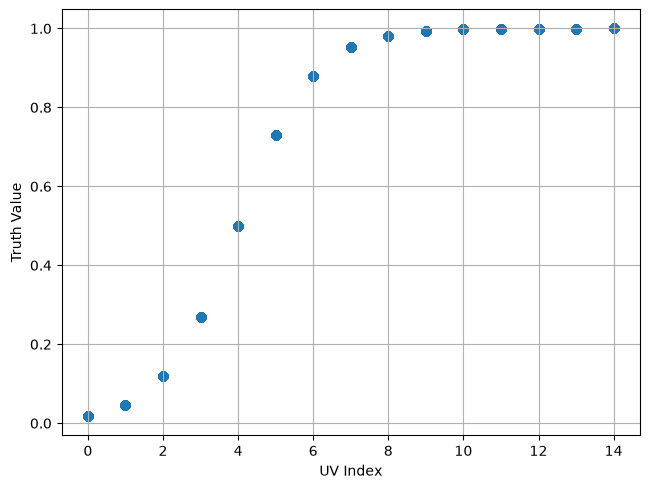

In [16]:
print(f'Learned condition: {x_condition.item():2.4f}')

x_pred_train = relaxation_fn(x_features_train, x_condition, STEEPNESS)

plt.scatter(x_features_train, x_pred_train)
plt.grid('on')
plt.tight_layout()
plt.xlabel(FEATURE_NAME)
plt.ylabel('Truth Value')

# Testing Metrics

In [17]:
x_pred_test = relaxation_fn(x_features_test, x_condition, STEEPNESS)

pred_dict_test = calculate_metrics(x_pred_test, x_target_test)

for m_name, m_val in pred_dict_test.items():
    print(f'{m_name:<10}:{m_val.item():2.2f}')

Accuracy  :86.25
TP        :617.00
TN        :1660.00
FP        :320.00
FN        :43.00
Precision :0.66
Recall    :0.93
F-1       :0.77


# Deduction with Modus Ponens and Tollens

In [18]:
# WE WILL USE THE F-1 AS CONFIDENCE INDICATOR
rule_confidence = pred_dict_test['F-1']

In [19]:
print('LEARNED RULE:')
print(f'If {FEATURE_NAME} > {x_condition.item():2.2f} THEN, CLASS: {TARGET_NAME}')
print(f'(Confidence: {rule_confidence:2.2f}%)')

LEARNED RULE:
If UV Index > 4.00 THEN, CLASS: Sunny
(Confidence: 0.77%)


In [20]:
def modus_ponens_inference(x, c, s, target, feature_name, target_name, p_str, q_str, verbose):
    p = relaxation_fn(x, c, s)
    q = target
        
    p_q = diff_imp_prob_sum(p, q)
    therefore = diff_and(p_q, p)
    
    if verbose:
        print(f'{p_str:<15} --> {q_str:<15}   (Truth: {p_q.item():2.2f})')
        print(f'{p_str:<18}                    (Truth: {p.item():2.2f})')
        print('-'*35)
        print(f'Therefore, {q_str:<18}         (Truth: {therefore.item():2.2f})')
        
    return therefore


def modus_tollens_inference(x, c, s, target, feature_name, target_name, p_str, q_str, verbose):
    p = relaxation_fn(x, c, s)
    q = target

    p_q = diff_imp_prob_sum(p, q)
    not_q = diff_not(q)
    therefore = diff_and(p_q, not_q)
    
    if verbose:
        print(f'{p_str:15} --> {q_str:<15}   (Truth: {p_q.item():2.2f})')
        print(f'NOT {q_str:<19}               (Truth: {not_q.item():2.2f})')
        print('-'*35)
        print(f'Therefore, NOT {p_str:<19}    (Truth: {therefore.item():2.2f})')
        
    return therefore

In [21]:
x_inference_feature = jnp.array((9.3,)) # assume FEATURE_NAME value
x_test_target = jnp.array((1,)) # assume TARGET_NAME is True

_p_str = f'{FEATURE_NAME} > {x_condition.item():2.2f}'
_class_str = TARGET_NAME if x_test_target == 1 else f'NOT {TARGET_NAME}'
_q_str = f'{_class_str}'

_ = modus_ponens_inference(
    x_inference_feature, 
    x_condition, 
    STEEPNESS, 
    x_test_target,
    FEATURE_NAME,
    TARGET_NAME,
    _p_str,
    _q_str,
    True
)

print('\n')

_ = modus_tollens_inference(
    x_inference_feature, 
    x_condition, 
    STEEPNESS, 
    x_test_target,
    FEATURE_NAME,
    TARGET_NAME,
    _p_str,
    _q_str,
    True
)

UV Index > 4.00 --> Sunny             (Truth: 1.00)
UV Index > 4.00                       (Truth: 1.00)
-----------------------------------
Therefore, Sunny                      (Truth: 1.00)


UV Index > 4.00 --> Sunny             (Truth: 1.00)
NOT Sunny                             (Truth: 0.00)
-----------------------------------
Therefore, NOT UV Index > 4.00        (Truth: 0.00)


## Iterative Deduction

In [22]:
def iterative_inference(x_f, x_c, steepness, feature_name, target_name, verbose):    
    # ASSUME BOTH TRUE AND FALSE, SELECT SUCESSFUL DEDUCTIONS!!
    for x_test_target in jnp.array((0, 1)):
        _p_str = f'{FEATURE_NAME} > {x_condition.item():2.2f}'
        _class_str = TARGET_NAME if x_test_target == 1 else f'NOT {TARGET_NAME}'
        _q_str = f'{_class_str}'
        
        therefore = modus_ponens_inference(
            x_f,
            x_c,
            steepness,
            x_test_target,
            feature_name, 
            target_name,
            _p_str,
            _q_str,
            verbose
        )
        print('*** MODUS PONENS ***')
        if binarize(therefore):
            print('  DEDUCTION SUCCESSFUL!')
        else:
            print('  DEDUCTION FAILED!')

        print()
    
        therefore = modus_tollens_inference(
            x_f,
            x_c,
            steepness,
            x_test_target,
            feature_name,
            target_name,
            _p_str,
            _q_str,
            verbose
        )
        print('*** MODUS TOLLENS ***')
        if binarize(therefore):
            print('  DEDUCTION SUCCESSFUL!')
        else:
            print('  DEDUCTION FAILED!')

        print()

### Perform Inference

In [23]:
x_inference_feature_range = jnp.linspace(1.0, 10.0, 5)
print(f'Inference feature samples: {x_inference_feature_range}')

Inference feature samples: [ 1.    3.25  5.5   7.75 10.  ]


In [24]:
for x_inference_feature in x_inference_feature_range:
    print(f'     #### ASSUME input {FEATURE_NAME}=={x_inference_feature.item():2.2f} ####')
    print()
    iterative_inference(x_inference_feature, x_condition, STEEPNESS, FEATURE_NAME, TARGET_NAME, True)
    print('     ########## END OF ITERATION ##########')
    print()

     #### ASSUME input UV Index==1.00 ####

UV Index > 4.00 --> NOT Sunny         (Truth: 0.95)
UV Index > 4.00                       (Truth: 0.05)
-----------------------------------
Therefore, NOT Sunny                  (Truth: 0.05)
*** MODUS PONENS ***
  DEDUCTION FAILED!

UV Index > 4.00 --> NOT Sunny         (Truth: 0.95)
NOT NOT Sunny                         (Truth: 1.00)
-----------------------------------
Therefore, NOT UV Index > 4.00        (Truth: 0.95)
*** MODUS TOLLENS ***
  DEDUCTION SUCCESSFUL!

UV Index > 4.00 --> Sunny             (Truth: 1.00)
UV Index > 4.00                       (Truth: 0.05)
-----------------------------------
Therefore, Sunny                      (Truth: 0.05)
*** MODUS PONENS ***
  DEDUCTION FAILED!

UV Index > 4.00 --> Sunny             (Truth: 1.00)
NOT Sunny                             (Truth: 0.00)
-----------------------------------
Therefore, NOT UV Index > 4.00        (Truth: 0.00)
*** MODUS TOLLENS ***
  DEDUCTION FAILED!

     #########

## Random Sample From Test Dataset

In [25]:
NUM_RANDOM_TRIALS = 10
current_key = jax.random.key(SEED)

for _ in range(NUM_RANDOM_TRIALS):
    current_key = jax.random.split(current_key, num=1)[0]
    random_idx = jax.random.randint(key=current_key, shape=(1,), minval=0, maxval=len(df_features_test)).item()
    
    sampled_feature = df_features_test.iloc[random_idx, :][FEATURE_NAME]
    sampled_target  = df_labels_test.iloc[random_idx]

    x_inference_feature = jnp.array((sampled_feature,))
    x_test_target = jnp.array((1 if sampled_target==TARGET_NAME else 0,))
    print(f'     ### {FEATURE_NAME}=={x_inference_feature.item():2.2f} EXPECTED: {sampled_target} ###')

    iterative_inference(x_inference_feature, x_condition, STEEPNESS, FEATURE_NAME, TARGET_NAME, True)
    print('\n')

     ### UV Index==-3.43 EXPECTED: Snowy ###
UV Index > 4.00 --> NOT Sunny         (Truth: 1.00)
UV Index > 4.00                       (Truth: 0.00)
-----------------------------------
Therefore, NOT Sunny                  (Truth: 0.00)
*** MODUS PONENS ***
  DEDUCTION FAILED!

UV Index > 4.00 --> NOT Sunny         (Truth: 1.00)
NOT NOT Sunny                         (Truth: 1.00)
-----------------------------------
Therefore, NOT UV Index > 4.00        (Truth: 1.00)
*** MODUS TOLLENS ***
  DEDUCTION SUCCESSFUL!

UV Index > 4.00 --> Sunny             (Truth: 1.00)
UV Index > 4.00                       (Truth: 0.00)
-----------------------------------
Therefore, Sunny                      (Truth: 0.00)
*** MODUS PONENS ***
  DEDUCTION FAILED!

UV Index > 4.00 --> Sunny             (Truth: 1.00)
NOT Sunny                             (Truth: 0.00)
-----------------------------------
Therefore, NOT UV Index > 4.00        (Truth: 0.00)
*** MODUS TOLLENS ***
  DEDUCTION FAILED!



     ### UV